In [1]:
import time
# autoreload
%load_ext autoreload
%autoreload 2

#from scipy import signal
#from scipy import interpolate
#from scipy import ndimage
import numpy as np
#import pycatch22 
#from sktime.transformations.panel import catch22
#import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
import random
load_dotenv = dotenv.load_dotenv('../.env')

# load local library
from timex import clustering
from timex import preprocessing

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

import datetime
from time import sleep

from aeon import datasets

c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#dataset = datasets.load_regression("FloodModeling1")
#dataset = datasets.load_japanese_vowels()
dataset = datasets.load_osuleaf()

In [3]:
dataset[0].shape

(442, 1, 427)

In [4]:
ts_data = pd.DataFrame(dataset[0].squeeze())
ts_label = dataset[1]

In [5]:
ts_label_df = pd.DataFrame()
ts_label_df['label'] = ts_label
ts_label_df['sample'] = range(442)

In [6]:
ts_data['sample'] = ts_data.index 
ts_data_unp = ts_data.melt(id_vars='sample', value_vars=list(range(ts_data.shape[1]-1)))\
                     .sort_values(by=['sample', 'variable'])
ts_data_unp = ts_data_unp.rename(columns = {'variable': 'Time'})

In [7]:
ts_data_unp

,sample,Time,value
0,0,0,0.550671
442,0,1,0.464716
884,0,2,0.375261
1326,0,3,0.293060
1768,0,4,0.206427
...,...,...,...
186965,441,422,1.761683
187407,441,423,1.838726
187849,441,424,1.927078
188291,441,425,2.004444


In [8]:
# create heterogeinity
MAX_CUT_PERC = 0.1
MAX_MASK_PERC = 0.25
MAX_TIME_OVERALL = 426

ts_data_unp_heter = pd.DataFrame()
for s in ts_data_unp['sample'].unique():
    temp_ts = ts_data_unp.loc[(ts_data_unp['sample']==s) & (ts_data_unp['Time']<MAX_TIME_OVERALL), ['sample', 'Time', 'value']]

    max_t = temp_ts['Time'].max()
    # randomly subtract from max_t 
    new_max_t = max_t - MAX_CUT_PERC*np.random.random()*max_t
    temp_ts = temp_ts.query(f'Time<{new_max_t}')

    # random mask from remainder
    val_rem = temp_ts['value'].values
    mask = np.random.rand(val_rem.shape[0]) < MAX_MASK_PERC
    val_rem[mask] = np.nan

    temp_ts = temp_ts.assign(value=val_rem)

    ts_data_unp_heter = pd.concat([ts_data_unp_heter, temp_ts], axis=0)

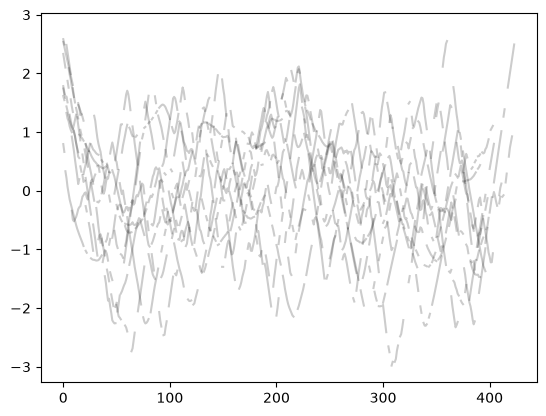

In [9]:
# plot 10 random samples
for s in ts_data_unp_heter.sample(n=10)['sample']:
    tsv = ts_data_unp_heter.query(f'sample=={s}')['value']
    tst = ts_data_unp_heter.query(f'sample=={s}')['Time']

    plt.plot(tst, tsv, color='black', alpha=0.2);

In [10]:
MIN_TIME = 1 
MAX_TIME = 450
MIN_MEAS_COUNT = 5 # measurements
NUM_CLUSTERS = 6
INTERP_RES = 1
ANALYSIS_RES = 1
SMOOTHING_WINDOW = 7
CLUSTERING_ALGO='gmm'
CLUSTER_KWARGS={"reg_covar": 1e-1, "covariance_type": "diag"}
SMOOTHING_TYPE = 'gaussian_kernel'  # 'gaussian_kernel' or 'rolling_mean', 'gaussian_kernel_simple, 'box_kernel'
META_KEYS = ['sample', 'Time']
ID_KEY = 'sample'
TIME_KEY = 'Time'
RAW_VAL_COL = 'value'

In [11]:
ts_data_unp_heter = ts_data_unp_heter.reset_index(drop=True)
ts_data_unp_heter = ts_data_unp_heter.dropna(subset='value')

In [12]:
ts_clusterer = clustering.CrossSectionalClustering(smoothing=True, 
                                                   smoothing_type=SMOOTHING_TYPE,
                                                   smoothing_window_size=SMOOTHING_WINDOW,
                                                   n_skip=2,
                                                   interpolation=True, 
                                                   interpolation_resolution=INTERP_RES,
                                                   interpolation_keep_init=True,
                                                   analysis_resolution=ANALYSIS_RES,
                                                   min_measurements_per_id=MIN_MEAS_COUNT, 
                                                   min_time=MIN_TIME,
                                                   max_time=MAX_TIME,
                                                   clustering_algorithm=CLUSTERING_ALGO,
                                                   n_clusters=NUM_CLUSTERS, 
                                                   cluster_kwargs=CLUSTER_KWARGS,
                                                   id_column=ID_KEY, 
                                                   time_column=TIME_KEY,
                                                   feature_columns=[RAW_VAL_COL],
                                                   imputation_method='knn',
                                                   cross_standardisation=True,
                                                   normalise_timeseries= "group",
                                                   normalisation_method="standard",
                                                   add_ts_meta=True,
                                                   verbose=True)

2026-06-23 16:11:31,872 - timex.clustering - DEBUG - CrossSectionalClustering initialized


In [13]:
nunique_samples = ts_data_unp_heter['sample'].nunique()
rand_selection = np.random.choice(ts_data_unp_heter['sample'].unique(), size=nunique_samples)
ts_clusterer.fit(ts_data_unp_heter.loc[ts_data_unp_heter['sample'].isin(rand_selection)])

2026-06-23 16:11:32,171 - timex.clustering - INFO - Starting CrossSectionalClustering.fit(); TS shape (82954, 3)


value


2026-06-23 16:11:32,171 - timex.clustering - INFO - Processing feature column: value
  0%|          | 0/274 [00:00<?, ?it/s]\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\preprocessing.py:119: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df = _df.replace([np.inf, -np.inf], np.nan).dropna(subset=[time_col, val_col])
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\preprocessing.py:119: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df = _df.replace([np.inf, -np.inf], np.nan)

Processing custom features..


  1%|          | 2/274 [00:00<00:25, 10.65it/s]c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\scipy\stats\_entropy.py:146: RuntimeWarning: divide by zero encountered in divide
  pk = 1.0*pk / xp.sum(pk, axis=axis, keepdims=True)  # type: ignore[operator]
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\extractor.py:1699: RuntimeWarning: divide by zero encountered in scalar divide
  return max_v / mean_v
 55%|█████▌    | 151/274 [00:15<00:09, 12.35it/s]\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\extractor.py:1027: RuntimeWarning: divide by zero encountered in log2
  entropy = np.nansum(psd_norm * np.log2(psd_norm))
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\extractor.py:1027: RuntimeWarning: invalid value encountered in multiply
  entropy = np.nansum(psd_norm * np.log2(psd_norm))
100%|██████████| 274/274 [00:24<00:00, 11.00it/s]
2026-06-23 16:11:59,

CrossSectionalClustering(add_ts_meta=True, analysis_resolution=1,
                         cluster_kwargs={'covariance_type': 'diag',
                                         'reg_covar': 0.1},
                         clustering_algorithm=GaussianMixture(covariance_type='diag',
                                                              n_components=6,
                                                              random_state=42,
                                                              reg_covar=0.1),
                         extractors={'antropy_features': False,
                                     'catch22_features': False,
                                     'cesium_features': False,
                                     'custom_features': True,
                                     'katz_feature...
                                     'tsfel_features': False,
                                     'tsfresh_features': False},
                         feature_columns=['value'], id_column='sample',
                         imputation_kwargs={}, interpolation=True,
                         interpolation_keep_init=True, interpolation_kwargs={},
                         max_time=450, min_measurements_per_id=5, min_time=1,
                         n_clusters=6, n_skip=2, smoothing=True,
                         smoothing_kwargs={}, smoothing_window_size=7,
                         time_column='Time', verbose=True)

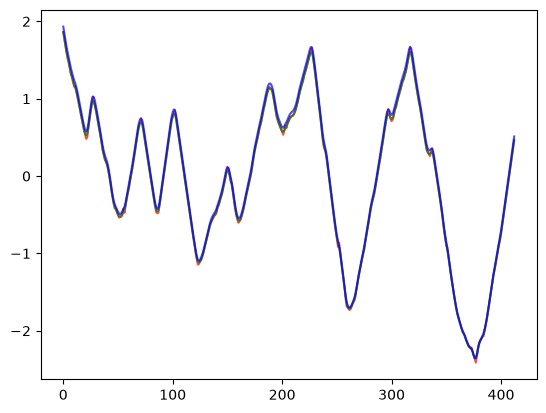

In [24]:
# plot 10 random samples
for s in ts_clusterer.ts_filtered.sample(n=1)['sample']:
    tsv = ts_clusterer.ts_filtered.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_filtered.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='red', alpha=0.7)

    tsv = ts_clusterer.ts_smoothed.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_smoothed.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='green', alpha=0.7)

    tsv = ts_clusterer.ts_smoothed_filtered.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_smoothed_filtered.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='blue', alpha=0.7)

In [15]:
res_cluster = pd.DataFrame(zip(ts_clusterer.ts_cross_combined.index, ts_clusterer.predict()), columns=['ID', 'cluster'])
res_cluster['cluster'] = res_cluster['cluster'].astype(int)
res_final = ts_data_unp_heter.merge(res_cluster, how='left', left_on='sample', right_on='ID').dropna(subset='ID')
res_final = res_final.merge(ts_label_df, how='left', left_on='sample', right_on='sample')

<Axes: xlabel='Time', ylabel='value'>

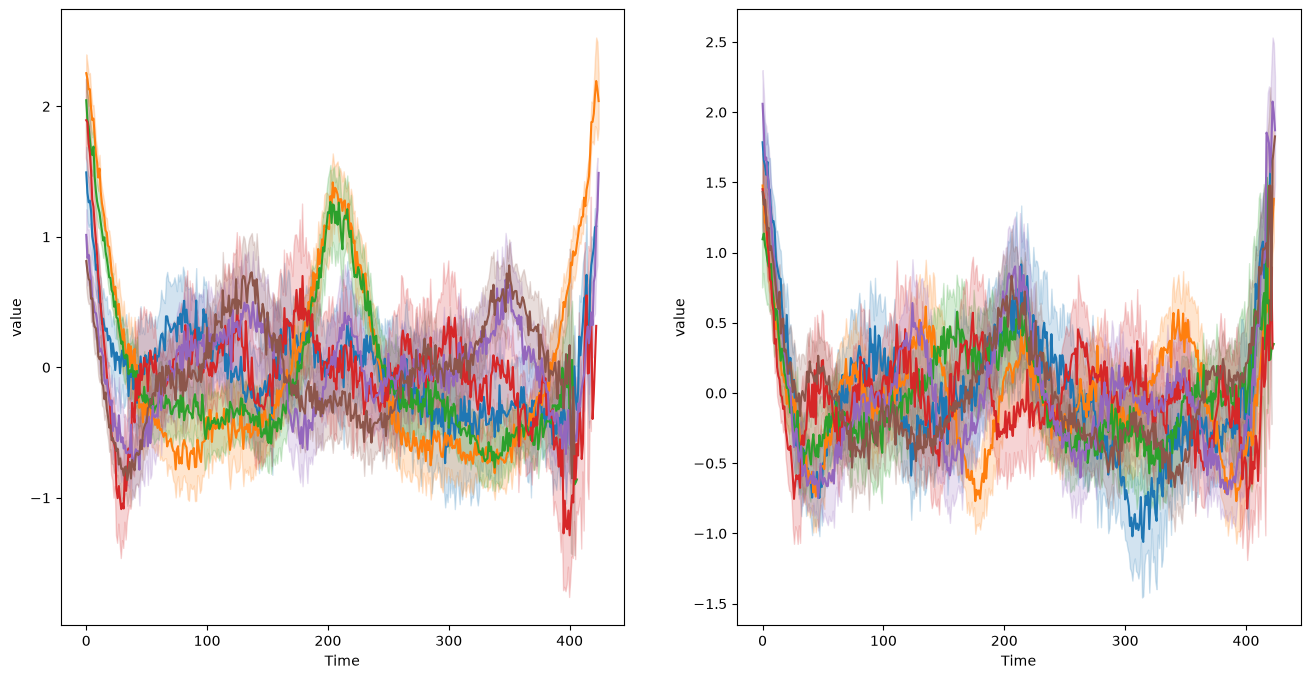

In [16]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='cluster',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[0],
             legend=False,)
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='label',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[1],
             legend=False,)

In [17]:
ts_clusterer.predict_proba()

array([[2.13300475e-075, 2.68345334e-120, 2.15840678e-036,
        1.40454250e-081, 4.24496541e-075, 1.00000000e+000],
       [1.22614097e-013, 4.56326072e-049, 2.97388424e-036,
        4.19793507e-015, 1.00000000e+000, 4.10497956e-030],
       [4.75225430e-064, 1.83229837e-069, 1.00000000e+000,
        1.89236201e-129, 1.30055120e-125, 1.35563600e-050],
       ...,
       [1.82572023e-035, 1.34400940e-073, 1.72311347e-005,
        4.64951516e-051, 1.41782172e-078, 9.99982769e-001],
       [7.36854364e-056, 5.46587551e-099, 9.62296221e-014,
        5.20287577e-055, 3.10205868e-071, 1.00000000e+000],
       [1.50661897e-028, 6.76613520e-025, 1.00000000e+000,
        1.26028868e-063, 2.87004496e-046, 3.62170047e-022]])

In [18]:
ts_clusterer.get_scores()

{'davies_bouldin': np.float64(2.7428902176755763),
 'calinski_harabasz': np.float64(17.028260671472243),
 'silhouette': np.float64(0.06725739316439967),
 'aic': np.float64(104123.78967251383),
 'bic': np.float64(110732.2009790976),
 'mep': np.float64(0.0018766601768399635),
 'mpp': np.float64(0.9996162880734701)}

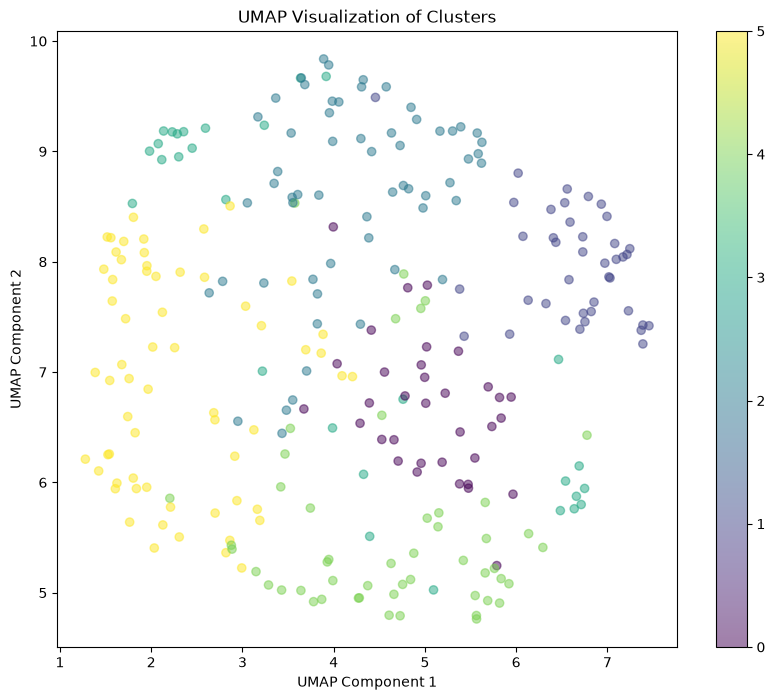

In [19]:
ts_clusterer.viz()

In [20]:
res_final['label'] = res_final['label'].astype(int)
alignment_df = res_final.groupby('sample')[['cluster', 'label']].agg('mean').astype(int)

In [21]:
random_label = np.random.randint(alignment_df['label'].max(), size=alignment_df.shape[0])
alignment_df = alignment_df.assign(random_label=random_label)

In [22]:
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

res_final.cluster = res_final.cluster.astype(int)

print(f"ARI: {adjusted_rand_score(alignment_df['cluster'], alignment_df['label'])}")
print(f"AMI: {adjusted_mutual_info_score(alignment_df['cluster'], alignment_df['label'])}")


print(f"ARI control: {adjusted_rand_score(alignment_df['cluster'], alignment_df['random_label'])}")
print(f"AMI control: {adjusted_mutual_info_score(alignment_df['cluster'], alignment_df['random_label'])}")


ARI: 0.10448313544533652
AMI: 0.17399464405267928
ARI control: -0.00032023749802428584
AMI control: -0.002323677769692949
